Längenmessung


In [1]:
import numpy as np
import uncertainties as unc
import uncertainties.unumpy as unp

In [2]:
err_scale = np.full(3, 0.1)

x_a = unp.uarray([98.5, 98.4, 98.5], err_scale)
x_o = unp.uarray([9.8, 9.9, 10], err_scale)
x_u = unp.uarray([7.6, 7.6, 7.55], err_scale)


In [3]:
L = x_a - 0.5*(x_o-x_u)
print(L)


sigma_stat = np.std(unp.nominal_values(L))/np.sqrt(len(L))
print(sigma_stat)

l_final = np.sqrt(sigma_stat**2 + unp.std_devs(L)**2/3)
print(l_final)

l_final/unp.nominal_values(L)

[97.4+/-0.12247448713915891 97.25+/-0.12247448713915891
 97.275+/-0.12247448713915891]
0.037883838047183906
[0.08021961 0.08021961 0.08021961]


array([0.00082361, 0.00082488, 0.00082467])

plot

Fitparameter: A0 = 18.23169±0.05405, k = 0.00020635±0.00000574


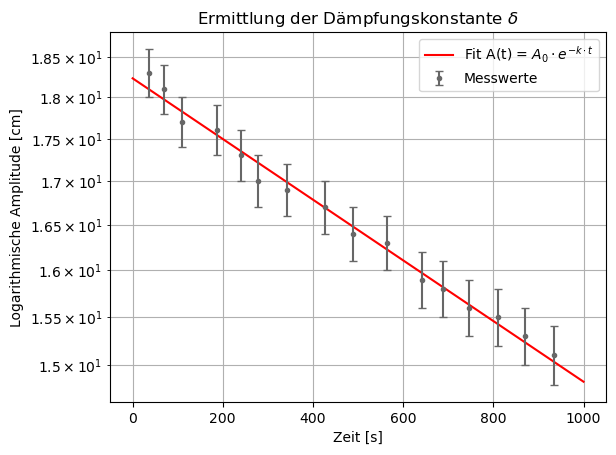

In [4]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


time = np.array([36.98, 70.1, 108.98, 186.18, 240.00, 278.99, 343.08, 426.48, 489.09, 564.50, 642.70, 687.58, 746.2, 810.4, 870.4, 933.49])

ampltude = np.array([18.30, 18.1, 17.7, 17.6, 17.3, 17.0, 16.9, 16.7, 16.4, 16.3, 15.9, 15.8, 15.6, 15.5, 15.3, 15.1]) 
err_a = 0.3

curve = lambda t, a, b: a*np.exp(-b*t)
popt, pcov = curve_fit(curve, time, ampltude, p0=(20, 0.001), sigma=err_a)

k = popt[1]

x = np.linspace(0, 1000, 100)
plt.plot(x, curve(x, *popt), '-', label=r'Fit A(t) = $A_0 \cdot e^{-k \cdot t}$', color='red')

plt.errorbar(time, ampltude, yerr=err_a, fmt='.', label=f'Messwerte', color='#676767', capsize=3)
plt.yscale('log')

plt.grid(True, which='both')
plt.xlabel('Zeit [s]')
plt.ylabel('Logarithmische Amplitude [cm]')
plt.legend()
plt.title(r'Ermittlung der Dämpfungskonstante $\delta$')


damping = unc.ufloat(k, np.sqrt(np.diag(pcov))[1])

A_0 = unc.ufloat(popt[0], np.sqrt(np.diag(pcov))[0])
print(f'Fitparameter: A0 = {A_0:.4uP}, k = {damping:.3uP}')


# Auswertung Versuch 14

Aufgabe 1

In [5]:
T = np.array([972.58, 972.53])
err_T = np.sqrt(0.21**2 + (np.std(T, ddof=1)/np.sqrt(len(T)))**2)

T = unc.ufloat(np.mean(T), err_T)
T_0 = unc.ufloat(T.n/514, T.s/514)
# hier unsicher mit T.s/514 oder nicht

L = unc.ufloat(97.31, 0.14) * 1e-2

print(f'{T_0=:.5f}')



T_0=1.89213+/-0.00041


In [6]:
g_mat = 4 * np.pi**2 * L / T_0**2
g_HD = unc.ufloat(9.80984, 0.0002)

print(f'{g_mat=:.5uP}')

(g_mat.n - g_HD.n)/np.sqrt(g_mat.s**2 + g_HD.s**2)

g_mat=10.730380±0.016128


np.float64(57.07370650962263)

Längenverhätnis Faden und Kugelradius

In [7]:
r = unc.ufloat(23.95, 0.05) * 1e-3 

k_1 = 2/5 * (r**2 / L**2) 

print(f'{k_1:.4e}')

(2.4230+/-0.0123)e-04


Berechnen Luftdichte

In [8]:
p_l = unc.ufloat(100990, 20)
Temp = unc.ufloat(294.15, 1)

rho_l = p_l / (287.05 * Temp)
rho_l 

1.1960572509816119+/-0.004073040660013633

Korrekturterm 2

In [9]:
rho_Fe = 7.86e3

k_2 = rho_l / rho_Fe
print(f'{k_2:.4e}')

(1.5217+/-0.0052)e-04


Korrekturterm 3

In [10]:
d_f = 0.2e-3

m_f = np.pi * (d_f/2)**2 * L * rho_Fe

m_K = 4/3 * np.pi * r**3 * rho_Fe

print(f'{m_f=:.4e}')
print(f'{m_K=:.4e}')

k_3 = -m_f / 6*m_K
print(f'{k_3:.4e}')

m_f=(2.4029+/-0.0035)e-04
m_K=(4.5230+/-0.0283)e-01
(-1.8114+/-0.0116)e-05


Dämpfung

In [11]:
w = 2 * np.pi / T_0
print(f'{w=:.4e}')

k_4 = damping**2 / w**2
print(f'{k_4=:.4e}')

w=(3.3207+/-0.0007)e+00
k_4=(3.8616+/-0.2149)e-09


Winkelausschlag

In [12]:

phi_0 = unp.arcsin(A_0*1e-2/L)

print(f'{phi_0=:.4e}')

k_5 = phi_0**2 / 8
print(f'{k_5=:.4e}')

phi_0=(1.8847+/-0.0063)e-01
k_5=(4.4401+/-0.0296)e-03


In [13]:
g_mat
korr = (1 + k_1 + k_2 + k_3 + k_4 + k_5)
g = g_mat * korr

print(f'{g=:.5uP}, {g_mat=:.5uP}, {korr=:.3uP}')

print(f'sigma weichung: {(g.n - g_HD.n)/np.sqrt(g.s**2 + g_HD.s**2)=:.2f}')

print(f'relative weichung: {(g.n - g_HD.n)*100/g_HD.n:.2f} ')

g_diff = g - g_mat

print(f'Abweichung Physikalisch zu Mathematisch: {g_diff} m/s²')
print(f'Abweichung Physikalisch zu Mathematisch in Sigma: {g_diff.n/np.sqrt(g.s**2 + g_mat.s**2):.2f} sigma')

g=10.782063±0.016068, g_mat=10.730380±0.016128, korr=1.0048165±0.0000300
sigma weichung: (g.n - g_HD.n)/np.sqrt(g.s**2 + g_HD.s**2)=60.50
relative weichung: 9.91 
Abweichung Physikalisch zu Mathematisch: 0.05168+/-0.00030 m/s²
Abweichung Physikalisch zu Mathematisch in Sigma: 2.27 sigma


In [14]:
L = x_a - 0.5*(x_o+x_u)
print(np.mean(L))


#NEEINN ICH HAB OBEN VERKACKT!!!!




89.72+/-0.07
